# **Лабораторна робота № 5**

## **Тема. Алгоритми пошуку**

## **Мета:** засвоїти варіанти реалізації алгоритмів пошуку засобами Python і методи оцінювання їх складності.

## **Виконав:** Гордієнко В.Ю.

### **Завдання 1:** Оцінити асимптотичну складність алгоритму лінійного пошуку в О-нотації.


Асимптотична складність: $O(n)$, оскільки час виконання алгоритму зростає прямо пропорційно кількості елементів у структурі даних.

### **Завдання 2:** Оцінити асимптотичну складність алгоритму бінарного пошуку в О-нотації.

Асимптотична складність: $O(\log n)$, оскільки на кожному кроці простір пошуку ділиться навпіл, навіть величезне збільшення вхідних даних призводить лише до незначного зростання кількості операцій.

### **Завдання 3:** Написати функцію, яка б могла повертати датафрейм з таким складом полів: («n», «time»), де n – розмір масиву для функції linear_searh();

In [1]:
import pandas as pd
import time

def get_performance_df(sizes):
    data = []
    
    for n in sizes:
        arr = list(range(n))
        
        start = time.perf_counter()
        for x in arr:
            if x == n - 1:
                break
        end = time.perf_counter()
        
        data.append({"n": n, "time": end - start})
    
    return pd.DataFrame(data)

test_sizes = [100000, 200000, 300000, 400000, 500000]
df = get_performance_df(test_sizes)
print(df)

        n      time
0  100000  0.004062
1  200000  0.006584
2  300000  0.009867
3  400000  0.013158
4  500000  0.016778


### **Завдання 4:** Написати функцію, яка б могла повертати датафрейм з таким складом полів: («n», «time»), де n – розмір масиву для функції bin_searh();

In [2]:
import pandas as pd
import time
import bisect

def get_bin_search_df(sizes):
    results = []
    
    for n in sizes:
        arr = list(range(n))
        target = n - 1  
        
        start = time.perf_counter()
        bisect.bisect_left(arr, target)
        end = time.perf_counter()
        
        results.append({
            "n": n, 
            "time": end - start
        })
        
    return pd.DataFrame(results)

sizes_list = [1000000, 2000000, 3000000, 4000000, 5000000]
df = get_bin_search_df(sizes_list)
print(df)

         n      time
0  1000000  0.000007
1  2000000  0.000008
2  3000000  0.000278
3  4000000  0.000010
4  5000000  0.000008


### **Завдання 5:** За результатами попередніх завдань побудувати графіки залежності часу виконання процедури пошуку від розміру масиву.

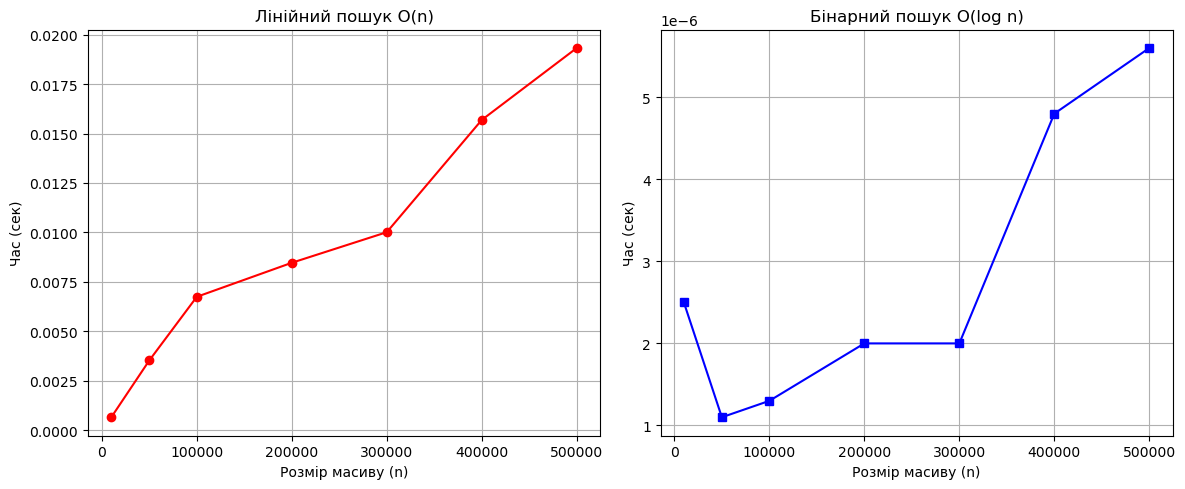

In [5]:
import matplotlib.pyplot as plt

sizes = [10000, 50000, 100000, 200000, 300000, 400000, 500000]

df_lin = get_performance_df(sizes)
df_bin = get_bin_search_df(sizes)
plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.plot(df_lin['n'], df_lin['time'], color='red', marker='o')
plt.title('Лінійний пошук O(n)')
plt.xlabel('Розмір масиву (n)')
plt.ylabel('Час (сек)')
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(df_bin['n'], df_bin['time'], color='blue', marker='s')
plt.title('Бінарний пошук O(log n)')
plt.xlabel('Розмір масиву (n)')
plt.ylabel('Час (сек)')
plt.grid(True)

plt.tight_layout()
plt.show()

### **Завдання 6:** Оцінити, який з двох алгоритмів є ефективнішим і в якому діапазоні розміру задачі.

Бінарний пошук є значно ефективнішим за лінійний на впорядкованих масивах будь-якого розміру, оскільки його складність $O(\log n)$ забезпечує майже миттєвий результат навіть при мільйонах елементів. Лінійний пошук ($O(n)$) доцільно використовувати лише для невідсортованих даних або дуже малих масивів (до 50–100 елементів), де різниця у часі виконання несуттєва, а складність реалізації та витрати на сортування не виправдовують використання бінарного підходу. 

## **Висновок:** після виконання лабораторної роботи я засвоїв варіанти реалізації алгоритмів пошуку засобами Python і методи оцінювання їх складності.

### **Контрольні питання:**
1. Сформулювати задачу пошуку.

Задача пошуку полягає у визначенні того, чи міститься певний елемент (аргумент пошуку) у заданій сукупності даних, та знаходженні його індексу або повного запису, що йому відповідає.
   
2. Які критерії можна використовувати для оцінювання ефективності алгоритмів пошуку?

Часова складність ($T$): кількість операцій (порівнянь), необхідних для знаходження елемента.

Просторова складність ($S$): обсяг додаткової пам'яті, яку використовує алгоритм під час роботи.

Середній, найкращий та найгірший випадки: аналіз поведінки алгоритму залежно від розташування шуканого елемента.

3. Що таке лінійний пошук і яка його асимптотична складність?

Лінійний пошук — це найпростіший метод, що полягає в послідовному переборі всіх елементів структури від початку до кінця, доки не буде знайдено збіг із ключем. Асимптотична складність: $O(n)$. 

4. Що таке бінарний (двійковий) пошук і в чому полягає його головний принцип роботи?

Бінарний (двійковий) пошук — це ефективний алгоритм для роботи з відсортованими даними. Головний принцип: «Розділяй і володарюй». Алгоритм порівнює ключ із середнім елементом масиву. Якщо ключ менший, пошук продовжується у лівій половині, якщо більший — у правій. На кожному кроці область пошуку скорочується вдвічі.

5. Які переваги і недоліки використання бінарного пошуку порівняно з лінійним?

Головна перевага бінарного пошуку — його колосальна швидкість на великих масивах ($O(\log n)$ проти $O(n)$ у лінійного), проте він має критичний недолік: алгоритм працює виключно з попередньо відсортованими даними, що вимагає додаткових витрат часу на сортування ($O(n \log n)$), тоді як лінійний пошук універсальний і простіший у реалізації.

6. Які ще алгоритми пошуку існують, окрім лінійного і бінарного?

Інтерполяційний пошук: вдосконалений бінарний пошук, який «вгадує» позицію елемента на основі його значення (ефективний для рівномірно розподілених даних).

Стрибковий пошук (Jump Search): перевірка елементів через фіксовані кроки (стрибки) з наступним лінійним пошуком у знайденому блоці.

Пошук за допомогою хеш-таблиць: забезпечує складність $O(1)$ у середньому випадку за рахунок використання хеш-функцій.

Експоненціальний пошук: використовується для пошуку в нескінченних або дуже великих масивах, спочатку визначаючи межі діапазону.